# Import Libraries

In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from datetime import datetime as dt

# Project Folders

In [5]:
from pathlib import Path

# Check current working directory if unsure
# print ("cwd:", Path.cwd())

# Set folder paths for project root, data, and outputs folders
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

# Ensure the folders exist: make the folders if they don't; skip if they do.

DATA_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

# Print and confirm 'absolute path'
print(DATA_DIR.resolve())

/Users/stephenhelvig/Documents/Python Projects/Citi Bike Strategy Dashboard/data


# Import Data

In [8]:
df = pd.read_csv(
    DATA_DIR / "cbsd_main_2022_02.csv",
    dtype={"start_station_id": "string", "end_station_id": "string"},
    low_memory=False
)

print(df.shape)
print(df.dtypes[["start_station_id", "end_station_id"]])

(29838166, 15)
start_station_id    string
end_station_id      string
dtype: object


In [9]:
df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'date', 'tavg_c'],
      dtype='str')

# Line plot of 2022 Temperatures

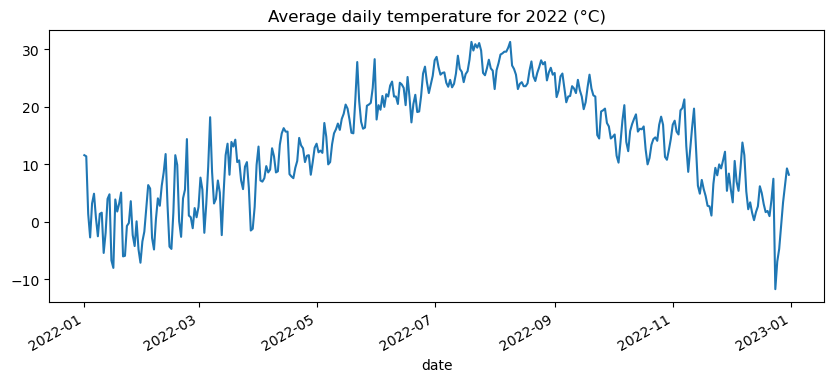

In [10]:
df_temp = df.copy()

df_temp["date"] = pd.to_datetime(df_temp["date"])
df_temp = df_temp.sort_values("date")
df_temp = df_temp.set_index("date")

df_temp["tavg_c"].plot(figsize=(10,4), title="Average daily temperature for 2022 (°C)")
plt.show()

In [11]:
# create a weather-only dataframe with date and average temperature

# Weather-only frame: one row per date with the temp column
wx = df[["date", "tavg_c"]].drop_duplicates(subset=["date"]).copy()

wx["date"] = pd.to_datetime(wx["date"])
wx = wx.sort_values("date")

print("wx shape:", wx.shape)
display(wx.head(3))

wx shape: (365, 2)


,date,tavg_c
27,2022-01-01,11.6
24,2022-01-02,11.4
3,2022-01-03,1.4


In [12]:
# Count trips per day
daily_trips = (
    df.groupby("date")["ride_id"]
      .count()
      .reset_index()
      .rename(columns={"ride_id": "bike_rides_daily"})
)

daily_trips["date"] = pd.to_datetime(daily_trips["date"])

In [13]:
# Merge into weather dataframe
wx = wx.merge(daily_trips, on="date", how="left")

print(wx.shape)
display(wx.head(5))

(365, 3)


,date,tavg_c,bike_rides_daily
0,2022-01-01,11.6,20428
1,2022-01-02,11.4,43009
2,2022-01-03,1.4,33189
3,2022-01-04,-2.7,36842
4,2022-01-05,3.2,34230


# Export Daily dataset for future use

In [26]:
# Make sure it's sorted and clean
wx = wx.sort_values("date").reset_index(drop=True)

# Optional: confirm one row per date
print("date unique:", wx["date"].is_unique)

# Save for reuse in future notebooks
wx.to_csv(DATA_DIR / "cbsd_daily_2022_01.csv", index=False)

date unique: True


# Create dual axis line chart for bike rides and temperature

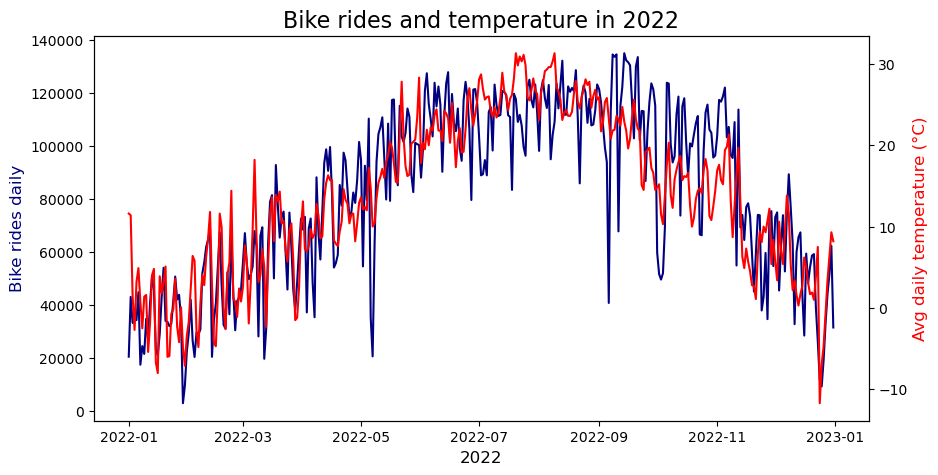

In [15]:
# Set date as index for clean plotting
wx_plot = wx.sort_values("date").set_index("date")

fig, ax = plt.subplots(figsize=(10, 5))

# Bike rides (left axis)
ax.plot(wx_plot["bike_rides_daily"], color="navy")
ax.set_xlabel("2022", fontsize=12)
ax.set_ylabel("Bike rides daily", color="navy", fontsize=12)

# Temperature (right axis)
ax2 = ax.twinx()
ax2.plot(wx_plot["tavg_c"], color="red")
ax2.set_ylabel("Avg daily temperature (°C)", color="red", fontsize=12)

plt.title("Bike rides and temperature in 2022", fontsize=16)
plt.show()

# Comments on the dual axis line chart
I used Matplotlib’s object-oriented approach to create a dual-axis line chart.

First, I prepared a plotting dataframe by sorting by date and setting date as the index so Matplotlib would treat it as a time series.

Then I created the main plot objects with fig, ax = plt.subplots(). The ax object was used to plot daily bike rides on the left y-axis and set the x/y labels.

To plot temperature on a different scale without flattening one of the lines, I created a second y-axis with ax2 = ax.twinx() and plotted tavg_c on that axis.

Finally, I added labels and a title to make the chart readable.

# Trip duration histogram

In [17]:
df.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'date', 'tavg_c'],
      dtype='str')

In [18]:
# ensure datetime
df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])

# trip duration in minutes
df["tripduration_min"] = (df["ended_at"] - df["started_at"]).dt.total_seconds() / 60

# quick check
df["tripduration_min"].describe()

count    2.983817e+07
mean     1.820962e+01
std      2.614485e+02
min     -5.728892e+01
25%      5.796733e+00
50%      1.016200e+01
75%      1.799900e+01
max      4.044810e+05
Name: tripduration_min, dtype: float64

In [19]:
# cleaning up negative trips and massive outliers
dur = df["tripduration_min"].dropna()

# keep plausible trips: 0 to 120 minutes
dur_clean = dur[(dur >= 0) & (dur <= 120)]

dur_clean.describe()

count    2.966847e+07
mean     1.401296e+01
std      1.289048e+01
min      1.488333e-01
25%      5.775267e+00
50%      1.010168e+01
75%      1.779520e+01
max      1.199996e+02
Name: tripduration_min, dtype: float64

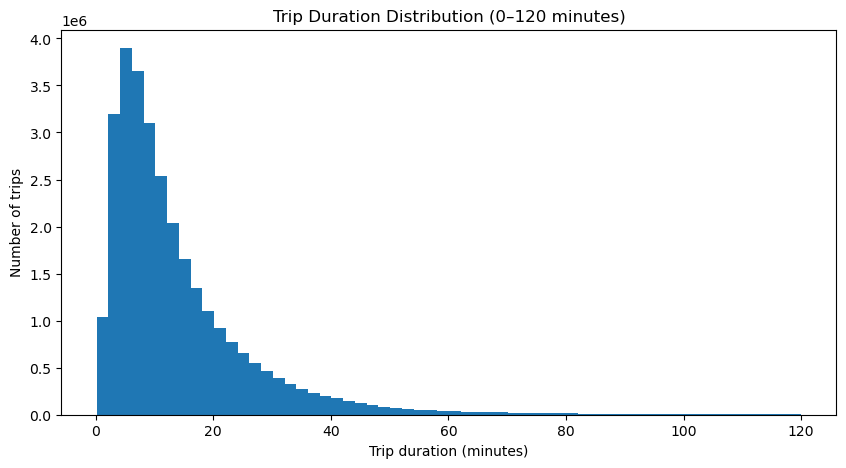

In [20]:
# plot drip duration histogram
plt.figure(figsize=(10, 5))
plt.hist(dur_clean, bins=60)
plt.title("Trip Duration Distribution (0–120 minutes)")
plt.xlabel("Trip duration (minutes)")
plt.ylabel("Number of trips")
plt.show()

In [22]:
import scipy
scipy.__version__

'1.17.0'

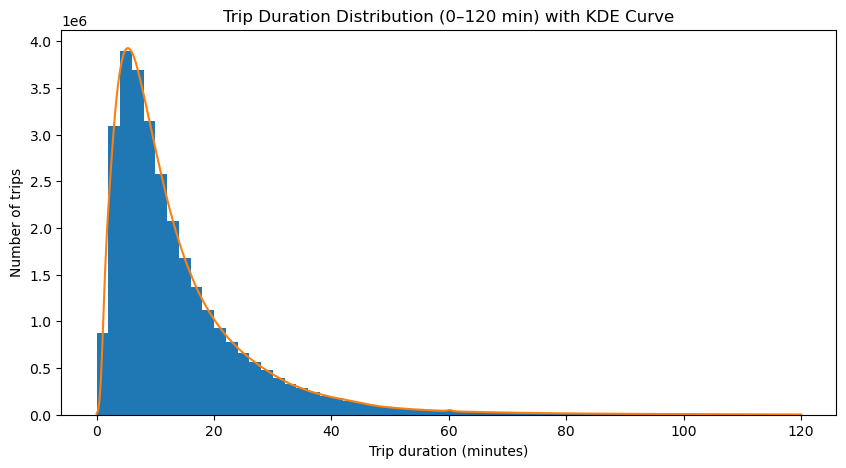

In [23]:
from scipy.stats import gaussian_kde

# Use the cleaned durations from earlier (0–120 min)
x = dur_clean.to_numpy()

bins = 60
xmin, xmax = 0, 120

# Histogram counts (so we can scale KDE to match)
counts, bin_edges = np.histogram(x, bins=bins, range=(xmin, xmax))
bin_width = bin_edges[1] - bin_edges[0]

# KDE evaluated on a smooth grid
grid = np.linspace(xmin, xmax, 500)
kde = gaussian_kde(x)
kde_counts = kde(grid) * len(x) * bin_width  # scale density -> counts

plt.figure(figsize=(10, 5))
plt.hist(x, bins=bins, range=(xmin, xmax))
plt.plot(grid, kde_counts)
plt.title("Trip Duration Distribution (0–120 min) with KDE Curve")
plt.xlabel("Trip duration (minutes)")
plt.ylabel("Number of trips")
plt.show()

# Two axes figure for 'usertype' and 'rideable type'

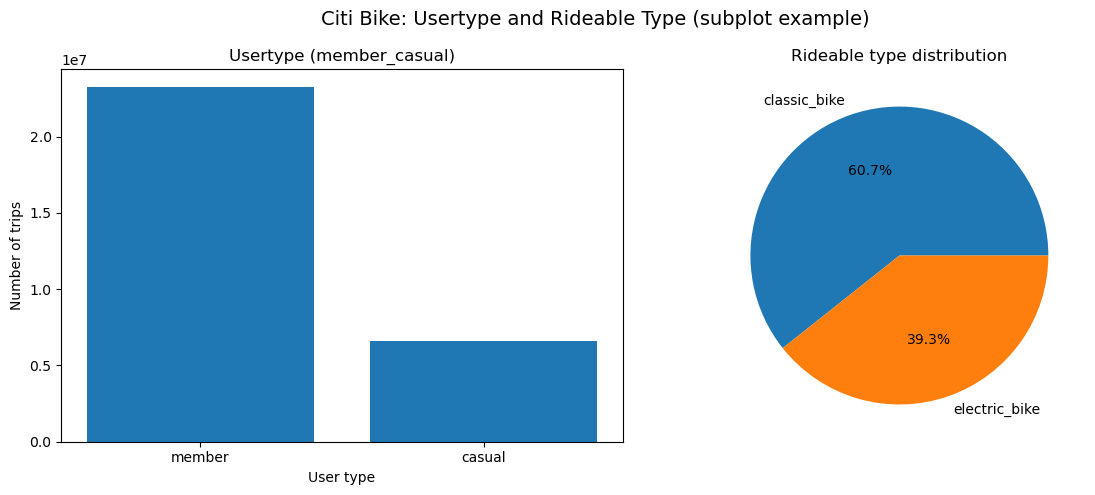

In [25]:
# counts for each categorical variable
usertype_counts = df["member_casual"].value_counts(dropna=False)
rideable_counts = df["rideable_type"].value_counts(dropna=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart (usertype)
ax[0].bar(usertype_counts.index.astype(str), usertype_counts.values)
ax[0].set_title("Usertype (member_casual)")
ax[0].set_xlabel("User type")
ax[0].set_ylabel("Number of trips")

# Pie chart (gender substitute)
ax[1].pie(rideable_counts.values, labels=rideable_counts.index.astype(str), autopct="%1.1f%%")
ax[1].set_title("Rideable type distribution")

plt.suptitle("Citi Bike: Usertype and Rideable Type (subplot example)", fontsize=14)
plt.tight_layout()
plt.show()

# Comments on the above visualization task
This bonus task asked for a bar chart of usertype and a pie chart of gender using Matplotlib’s object-oriented approach with multiple axes.

In the 2022 Citi Bike dataset I used here, a gender field is not available, so I used rideable_type as a categorical substitute for the pie chart to demonstrate the same subplot concept.

I created the figure and axes with fig, ax = plt.subplots(1, 2, ...), then plotted the bar chart on ax[0] and the pie chart on ax[1]. This produces two separate plots within the same figure (subplots), which is different from a dual-axis chart (twinx()).